# Explorative Datenanalyse der NBA Wurfdaten

This script performs an exploratory data analysis (EDA) of the file
`nba_raw_shot_data.parquet`. The focus is on impact value analytics –
insights that directly inform the assessment and improvement of shot quality.

The script is jupytext-compatible and can be synced as a notebook.

## Import der nötigen Bibliotheken

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.append("../utils")
from utils import *

## Setup
- Seaborn and Matplotlib styles
- Output directory for figures

In [2]:
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

FIGURES_DIR = Path("../figures/eda")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Laden der Daten

In [3]:
shot_data = load_data(file_path="../data/raw/nba_raw_shot_data.parquet")

## Teil 1: Allgemeine Datenübersicht

### Datenzusammenfassung

In [4]:
summarize_data(shot_data)

DATAFRAME OVERVIEW SUMMARY


,Rows,Columns,Memory (MB)
0,1251268,28,1139.59



Total rows: 1.251.268
Total memory usage: 1139.59 MB


### Detailiertere Untersuchung

In [5]:
explore_data(shot_data)


Column Information:


,Column,Data Type,Non-Null Count,Null Count,Null %
0,GRID_TYPE,object,1251268,0,0.0
1,GAME_ID,object,1251268,0,0.0
2,GAME_EVENT_ID,int64,1251268,0,0.0
3,PLAYER_ID,int64,1251268,0,0.0
4,PLAYER_NAME,object,1251268,0,0.0
5,TEAM_ID,int64,1251268,0,0.0
6,TEAM_NAME,object,1251268,0,0.0
7,PERIOD,int64,1251268,0,0.0
8,MINUTES_REMAINING,int64,1251268,0,0.0
9,SECONDS_REMAINING,int64,1251268,0,0.0



First 3 Rows:


,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,PLAYER_SEASON_FG_PCT,PLAYER_SEASON_3P_PCT,PLAYER_SEASON_FT_PCT,SEASON
0,Shot Chart Detail,0021900001,7,1628366,Lonzo Ball,1610612740,New Orleans Pelicans,1,11,48,Missed Shot,Driving Floating Jump Shot,2PT Field Goal,In The Paint (Non-RA),Center(C),8-16 ft.,11,2,114,1,0,20191022,TOR,NOP,0.403,0.375,0.566,2019-20
1,Shot Chart Detail,0021900001,9,202324,Derrick Favors,1610612740,New Orleans Pelicans,1,11,47,Made Shot,Tip Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,0,0,-6,1,1,20191022,TOR,NOP,0.617,0.143,0.563,2019-20
2,Shot Chart Detail,0021900001,10,1628384,OG Anunoby,1610612761,Toronto Raptors,1,11,29,Missed Shot,Driving Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,3,15,28,1,0,20191022,TOR,NOP,0.505,0.390,0.706,2019-20



Last 3 Rows:


,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,PLAYER_SEASON_FG_PCT,PLAYER_SEASON_3P_PCT,PLAYER_SEASON_FT_PCT,SEASON
1251265,Shot Chart Detail,0022401230,715,1629652,Luguentz Dort,1610612760,Oklahoma City Thunder,4,0,24,Made Shot,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,24,186,167,1,1,20241214,OKC,HOU,0.435,0.412,0.717,2024-25
1251266,Shot Chart Detail,0022401230,719,1630224,Jalen Green,1610612745,Houston Rockets,4,0,13,Made Shot,Driving Finger Roll Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,2,12,16,1,1,20241214,OKC,HOU,0.423,0.354,0.813,2024-25
1251267,Shot Chart Detail,0022401230,724,1630224,Jalen Green,1610612745,Houston Rockets,4,0,0,Missed Shot,Pullup Jump shot,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,25,-218,132,1,0,20241214,OKC,HOU,0.423,0.354,0.813,2024-25



5 Random Sample Rows:


,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,PLAYER_SEASON_FG_PCT,PLAYER_SEASON_3P_PCT,PLAYER_SEASON_FT_PCT,SEASON
371269,Shot Chart Detail,0022001037,189,1629029,Luka Dončić,1610612742,Dallas Mavericks,2,8,46,Missed Shot,Step Back Jump shot,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,25,131,218,1,0,20210511,MEM,DAL,0.479,0.350,0.730,2020-21
507806,Shot Chart Detail,0022100731,445,1627863,Danuel House Jr.,1610612762,Utah Jazz,3,2,59,Missed Shot,Pullup Jump shot,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,25,-181,179,1,0,20220126,UTA,PHX,0.404,0.376,0.759,2021-22
998770,Shot Chart Detail,0022301045,178,1629060,Rui Hachimura,1610612747,Los Angeles Lakers,2,9,50,Made Shot,Turnaround Jump Shot,2PT Field Goal,In The Paint (Non-RA),Left Side(L),8-16 ft.,10,-70,79,1,1,20240326,MIL,LAL,0.537,0.422,0.739,2023-24
942702,Shot Chart Detail,0022300728,76,1629731,Dean Wade,1610612739,Cleveland Cavaliers,1,5,45,Missed Shot,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,26,179,194,1,0,20240207,WAS,CLE,0.414,0.391,0.769,2023-24
407603,Shot Chart Detail,0022100161,156,1630167,Obi Toppin,1610612752,New York Knicks,2,11,12,Missed Shot,Jump Shot,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,24,-201,132,1,0,20211110,NYK,MIL,0.531,0.308,0.758,2021-22


### Duplikat-Analyse

In [6]:
summarize_duplicates(shot_data)

DUPLICATE RECORDS SUMMARY


,Total Rows,Duplicate Rows,Duplicate %
0,1251268,0,0.0


### Datentypen und Statistiken

In [7]:
summarize_data_types_and_stats(shot_data)


Numeric columns (14): ['GAME_EVENT_ID', 'PLAYER_ID', 'TEAM_ID', 'PERIOD', 'MINUTES_REMAINING', 'SECONDS_REMAINING', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'PLAYER_SEASON_FG_PCT', 'PLAYER_SEASON_3P_PCT', 'PLAYER_SEASON_FT_PCT']
Datetime columns (0): []
Categorical columns (14): ['GRID_TYPE', 'GAME_ID', 'PLAYER_NAME', 'TEAM_NAME', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'GAME_DATE', 'HTM', 'VTM', 'SEASON']

Checking for potential issues in numeric columns:


,Column,Count,Unique Count,Min,Max,Contains Negative?,Zero Count
0,GAME_EVENT_ID,1251268,875,3.000000e+00,8.960000e+02,False,0
1,PLAYER_ID,1251268,1058,1.713000e+03,1.642530e+06,False,0
2,TEAM_ID,1251268,30,1.610613e+09,1.610613e+09,False,0
3,PERIOD,1251268,7,1.000000e+00,7.000000e+00,False,0
4,MINUTES_REMAINING,1251268,13,0.000000e+00,1.200000e+01,False,121420
5,SECONDS_REMAINING,1251268,60,0.000000e+00,5.900000e+01,False,33194
6,SHOT_DISTANCE,1251268,89,0.000000e+00,8.800000e+01,False,93831
7,LOC_X,1251268,501,-2.500000e+02,2.500000e+02,True,51378
8,LOC_Y,1251268,855,-5.200000e+01,8.780000e+02,True,40303
9,SHOT_ATTEMPTED_FLAG,1251268,1,1.000000e+00,1.000000e+00,False,0



Categorical Column Summary:


,Column,Count,Unique Count,Top Value 1,Top Value 1 Count
0,GRID_TYPE,1251268,1,Shot Chart Detail,1251268
1,GAME_ID,1251268,7059,0022401189,234
2,PLAYER_NAME,1251268,1058,Jayson Tatum,8558
3,TEAM_NAME,1251268,30,Memphis Grizzlies,43415
4,EVENT_TYPE,1251268,2,Missed Shot,666203
5,ACTION_TYPE,1251268,48,Jump Shot,390924
6,SHOT_TYPE,1251268,2,2PT Field Goal,754686
7,SHOT_ZONE_BASIC,1251268,7,Restricted Area,371772
8,SHOT_ZONE_AREA,1251268,6,Center(C),707903
9,SHOT_ZONE_RANGE,1251268,5,Less Than 8 ft.,509419


### Ausreißer-Analyse

In [8]:
detect_outliers_iqr(shot_data)

Detecting outliers using IQR method (1.5 × IQR):

Outlier Summary:


,Column,Outlier_Count,Outlier_Percent,Lower_Bound,Upper_Bound
0,PERIOD,30,0.00,-2.00,6.00
1,SHOT_DISTANCE,727,0.06,-30.00,58.00
2,LOC_X,194011,15.51,-190.00,186.00
3,LOC_Y,2287,0.18,-239.50,436.50
4,PLAYER_SEASON_FG_PCT,74440,5.95,0.33,0.59
5,PLAYER_SEASON_3P_PCT,86220,6.89,0.22,0.49
6,PLAYER_SEASON_FT_PCT,31221,2.50,0.56,1.02



INTERPRETATION NEEDED:
Review the detected outliers carefully:
  - ID/counter columns → usually ignore
  - Incorrect values → remove/cap
  - Valid but extreme values → keep
  - Domain-specific exceptions → contextual decision


,Column,Outlier_Count,Outlier_Percent,Lower_Bound,Upper_Bound
0,PERIOD,30,0.00,-2.00,6.00
1,SHOT_DISTANCE,727,0.06,-30.00,58.00
2,LOC_X,194011,15.51,-190.00,186.00
3,LOC_Y,2287,0.18,-239.50,436.50
4,PLAYER_SEASON_FG_PCT,74440,5.95,0.33,0.59
5,PLAYER_SEASON_3P_PCT,86220,6.89,0.22,0.49
6,PLAYER_SEASON_FT_PCT,31221,2.50,0.56,1.02


## Teil 2: Erweiterte Analyse und Visualisierungen

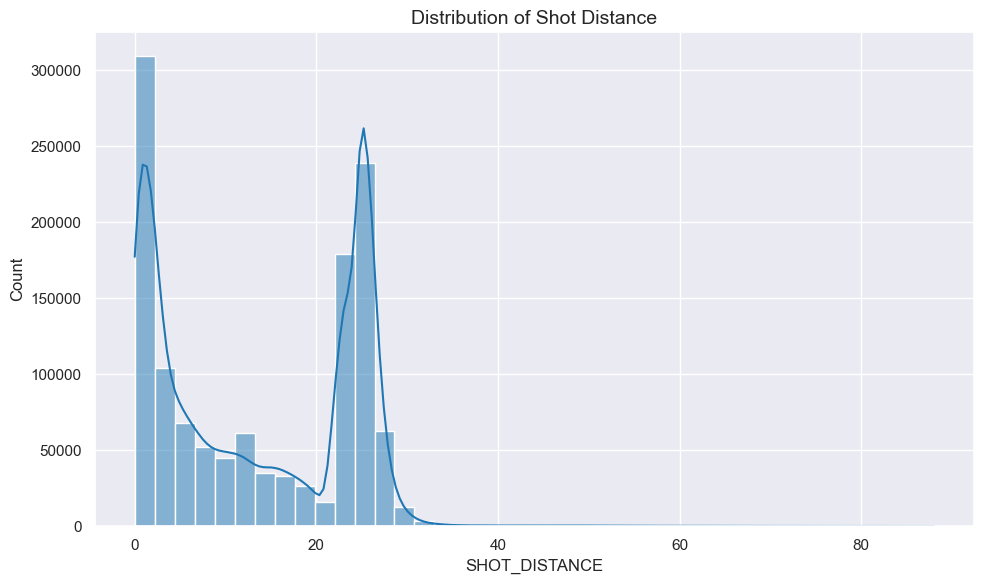

/Users/melihkoc/Desktop/HM/7.Semester/shot-decision-optimizer/notebooks/../utils/utils.py:307: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("distance_bin")[outcome_col]


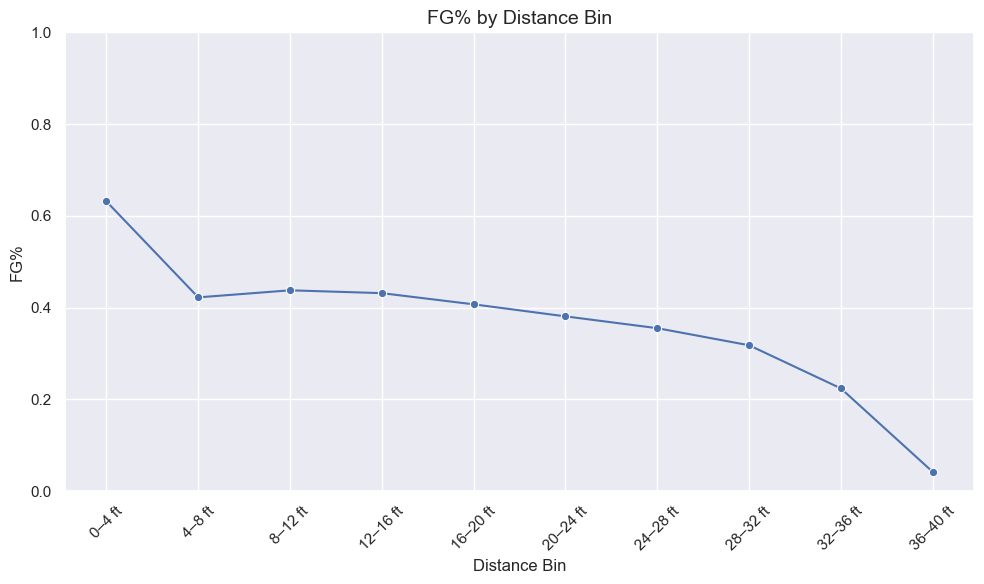

In [9]:
plot_distance_profile(shot_data)

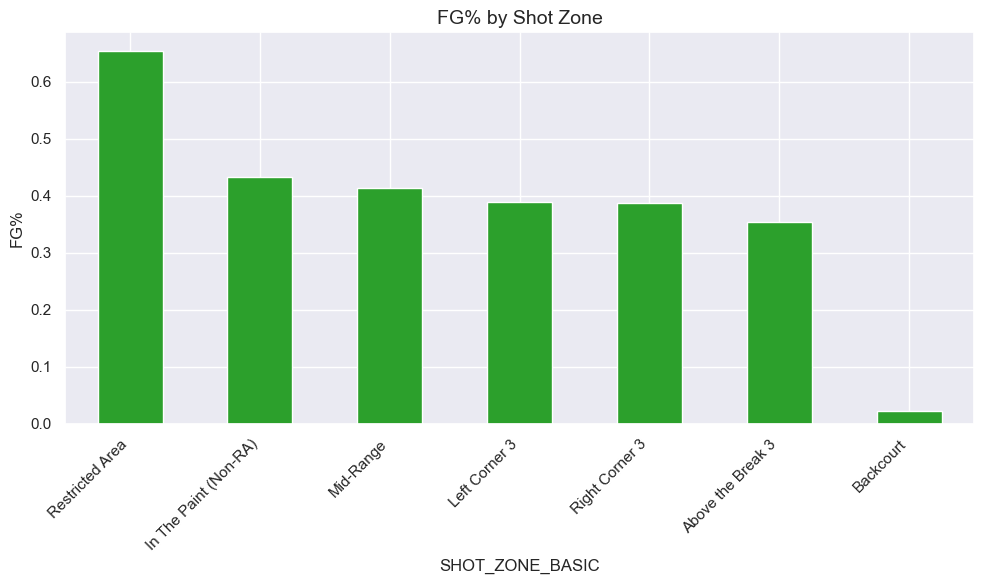

In [10]:
plot_zone_efficiency(shot_data)

In [11]:
plot_time_pressure(shot_data)

Time-pressure analysis skipped (missing time or outcome columns).


## Teil 3: Interaktive Dashboards

In [12]:
PLAYERS_OF_INTEREST = [
    "LeBron James",
    "Stephen Curry",
    "James Harden",
    "Kevin Durant",
    "Paul George",
    "Nikola Jokic"
]

# Filter to available players
available_players = [
    p for p in PLAYERS_OF_INTEREST 
    if p in shot_data['PLAYER_NAME'].values
]

TEAM_NAMES = sorted(shot_data['TEAM_NAME'].unique())
SEASONS = sorted(shot_data['SEASON'].unique())

print(f"Available players: {available_players}")
print(f"Available teams: {len(TEAM_NAMES)}")
print(f"Available seasons: {SEASONS}")

Available players: ['LeBron James', 'Stephen Curry', 'James Harden', 'Kevin Durant', 'Paul George']
Available teams: 30
Available seasons: ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']


### HEX Shot Chart

In [13]:
# Dropdown for players
player_dropdown = Dropdown(
    options=available_players,
    description='Player:',
    style={'description_width': '120px'}
)

# Multi-select for seasons
season_select = SelectMultiple(
    options=SEASONS,
    value=[SEASONS[-1]],  # Default: last season
    description='Seasons:',
    rows=3,
    style={'description_width': '120px'}
)

# Output for plot
output_shot_chart = Output()

def update_shot_chart(player, seasons):
    """Update shot chart based on widget values."""
    with output_shot_chart:
        output_shot_chart.clear_output(wait=True)
        if not seasons:
            print("Please select at least one season.")
        else:
            fig = plot_hex_shot_chart(shot_data, player, list(seasons))
            fig.show()

# Widget observers
player_dropdown.observe(
    lambda change: update_shot_chart(player_dropdown.value, season_select.value),
    names='value'
)
season_select.observe(
    lambda change: update_shot_chart(player_dropdown.value, season_select.value),
    names='value'
)

# Layout for shot chart
shot_chart_controls = VBox([
    HBox([player_dropdown, season_select]),
    output_shot_chart
])

print("SHOT CHART")
shot_chart_controls

SHOT CHART


In [14]:
update_shot_chart(player_dropdown.value, season_select.value)

In [15]:
# Dropdown for teams
team_dropdown = Dropdown(
    options=TEAM_NAMES,
    description='Team:',
    style={'description_width': '120px'}
)

# Dropdown for season
season_dropdown = Dropdown(
    options=SEASONS,
    value=SEASONS[-1],  # Default: last season
    description='Season:',
    style={'description_width': '120px'}
)

# Output for PPP plot
output_ppp_heatmap = Output()

def update_ppp_heatmap(team, season):
    """Update PPP heatmap based on widget values."""
    with output_ppp_heatmap:
        output_ppp_heatmap.clear_output(wait=True)
        ppp_matrix = calculate_ppp(shot_data, team, season, top_n=10)
        fig = plot_ppp_heatmap(ppp_matrix, team, season)
        fig.show()

# Widget observers
team_dropdown.observe(
    lambda change: update_ppp_heatmap(team_dropdown.value, season_dropdown.value),
    names='value'
)
season_dropdown.observe(
    lambda change: update_ppp_heatmap(team_dropdown.value, season_dropdown.value),
    names='value'
)

# Layout for PPP heatmap
ppp_controls = VBox([
    HBox([team_dropdown, season_dropdown]),
    output_ppp_heatmap
])

print("PPP HEATMAP")
ppp_controls

PPP HEATMAP


In [16]:
update_ppp_heatmap(team_dropdown.value, season_dropdown.value)